# Periscope Labs — Mini Loan Default Predictor
## Parts A, B, C: Data Audit → Model Building → Explanations

**Author:** Farhan  
**Dataset:** Lending Club (accepted_2007_to_2018Q4.csv)  
**Random seed:** 42 (fixed throughout)

---
## 0. Setup & Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve
)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

os.makedirs('../models', exist_ok=True)
os.makedirs('../explanations', exist_ok=True)

print('All imports successful.')

All imports successful.


---
## Part A — Data Loading, Sampling & Leakage Audit

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Load & subsample
# Replace this path with wherever you stored the downloaded file
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '../data/accepted_2007_to_2018Q4.csv'  # <-- UPDATE THIS PATH

# Load only the columns we actually need (saves memory on the full 2M row file)
COLS_TO_LOAD = [
    # Target
    'loan_status',
    # Static / application-time features
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'annual_inc', 'verification_status', 'purpose', 'dti',
    'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc',
    'earliest_cr_line', 'issue_d',
    # Behavioral / derived inputs
    'mths_since_last_delinq', 'mths_since_last_record',
    'total_rev_hi_lim', 'avg_cur_bal', 'bc_open_to_buy',
    'pct_tl_nvr_dlq', 'num_accts_ever_120_pd',
    # ID for reference
    'id'
]

print('Reading CSV... (this may take 30-60 seconds for the full file)')
df_raw = pd.read_csv(DATA_PATH, usecols=COLS_TO_LOAD, low_memory=False)
print(f'Raw shape: {df_raw.shape}')

Reading CSV... (this may take 30-60 seconds for the full file)
Raw shape: (2260701, 32)


In [8]:
df_raw['loan_status'].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan,
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Filter to resolved loans (drop 'Current' — no outcome yet)
# ─────────────────────────────────────────────────────────────────────────────
DEFAULT_STATUSES = ['Charged Off', 'Default', 'Late (31-120 days)']
RESOLVED_STATUSES = DEFAULT_STATUSES + ['Fully Paid']

df_resolved = df_raw[df_raw['loan_status'].isin(RESOLVED_STATUSES)].copy()
print(f'After filtering to resolved loans: {df_resolved.shape}')

# Subsample to 50,000 rows with fixed seed
df = df_resolved.sample(n=50_000, random_state=SEED).reset_index(drop=True)
print(f'Subsampled shape: {df.shape}')


After filtering to resolved loans: (1366817, 32)
Subsampled shape: (50000, 32)


In [32]:
df['loan_status'].unique()
df['emp_length'].unique()
df['purpose'].unique()
df.head(10)

,id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,...,purpose_clean_small_business,log_annual_inc,log_revol_bal,issue_d_parsed,earliest_cr_line_parsed,credit_age_months,revol_bal_to_limit,loan_to_income,mths_since_last_delinq_filled,ever_120dpd
0,32198425,25000.0,60.0,14.49,588.08,C,C4,10.0,131000.0,Verified,...,False,11.782960,10.431023,2014-10-01,1993-05-01,256.997372,0.614011,0.190838,999.0,0
1,84626363,10000.0,36.0,11.49,329.72,B,B5,10.0,92368.0,Not Verified,...,False,11.433547,8.531096,2016-08-01,2004-09-01,142.969777,0.140412,0.108261,6.0,1
2,122293905,4200.0,36.0,7.21,130.09,A,A3,10.0,42000.0,Verified,...,False,10.645449,4.795791,2017-11-01,1993-10-01,288.994744,0.008391,0.099998,70.0,0
3,35763750,19225.0,60.0,17.86,486.73,D,D5,10.0,48138.0,Verified,...,False,10.781848,9.257987,2014-11-01,1995-08-01,231.011827,0.379606,0.399364,999.0,0
4,11085115,7850.0,36.0,13.98,268.22,C,C1,4.0,26000.0,Not Verified,...,False,10.165890,8.905037,2014-01-01,2005-08-01,101.018397,0.175008,0.301911,999.0,0
5,62012314,12300.0,36.0,12.69,412.61,C,C2,4.0,28000.0,Source Verified,...,False,10.239996,9.627866,2015-10-01,2003-12-01,141.984231,0.709359,0.439270,999.0,0
6,50263594,20000.0,36.0,6.24,610.62,A,A2,10.0,48000.0,Source Verified,...,False,10.778977,9.822765,2015-06-01,2001-09-01,164.947438,0.798580,0.416658,999.0,0
7,96197982,18900.0,60.0,25.49,560.19,E,E4,5.0,75000.0,Source Verified,...,False,11.225257,9.034319,2017-01-01,2002-03-01,178.055191,0.616499,0.251997,30.0,0
8,84536269,18000.0,60.0,26.99,549.53,F,F3,10.0,93000.0,Verified,...,False,11.440366,10.426410,2016-07-01,1997-01-01,233.935611,0.843429,0.193546,999.0,0
9,61381341,12000.0,36.0,7.26,371.96,A,A4,6.0,40000.0,Verified,...,False,10.596660,5.929589,2015-10-01,2000-03-01,186.990802,0.023583,0.299993,74.0,1



=== CLASS DISTRIBUTION ===
Non-default (0): 39,557 (79.1%)
Default     (1): 10,443 (20.9%)

Default rate: 0.209


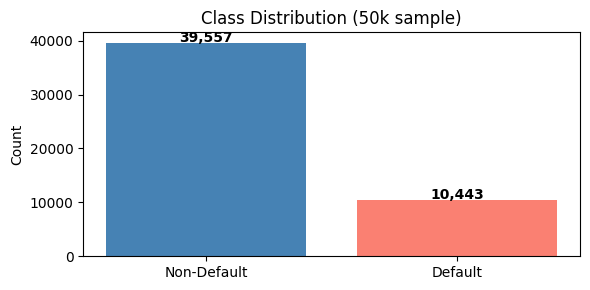

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Define target & check class imbalance
# ─────────────────────────────────────────────────────────────────────────────
df['default'] = df['loan_status'].isin(DEFAULT_STATUSES).astype(int)

class_counts = df['default'].value_counts()
default_rate = df['default'].mean()

print('\n=== CLASS DISTRIBUTION ===')
print(f"Non-default (0): {class_counts[0]:,} ({100*(1-default_rate):.1f}%)")
print(f"Default     (1): {class_counts[1]:,} ({100*default_rate:.1f}%)")
print(f"\nDefault rate: {default_rate:.3f}")

# Visual
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(['Non-Default', 'Default'], [class_counts[0], class_counts[1]],
       color=['steelblue', 'salmon'])
ax.set_title('Class Distribution (50k sample)')
ax.set_ylabel('Count')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part B — Feature Engineering & Model Building

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Clean application-time static features
# ─────────────────────────────────────────────────────────────────────────────

def clean_static_features(df):
    df = df.copy()

    # term: " 36 months" → 36
    df['term'] = df['term'].str.strip().str.extract('(\d+)').astype(float)

    # int_rate: "10.5%" → 10.5 (sometimes already float)
    if df['int_rate'].dtype == object:
        df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

    # emp_length: "10+ years" → 10, "< 1 year" → 0, "n/a" → NaN
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8, '9 years': 9, '10+ years': 10
    }
    df['emp_length'] = df['emp_length'].map(emp_map)
    df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

    # home_ownership: encode
    df['home_ownership'] = df['home_ownership'].replace(
        {'NONE': 'OTHER', 'ANY': 'OTHER'}
    )
    df = pd.get_dummies(df, columns=['home_ownership'], drop_first=False)

    # grade: ordinal encode A=0 ... G=6
    grade_map = {g: i for i, g in enumerate('ABCDEFG')}
    df['grade_num'] = df['grade'].map(grade_map).fillna(3)

    # verification_status
    verif_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
    df['verification_num'] = df['verification_status'].map(verif_map).fillna(0)

    # purpose: encode top categories, rest → 'other'
    top_purposes = df['purpose'].value_counts().head(8).index
    df['purpose_clean'] = df['purpose'].where(df['purpose'].isin(top_purposes), 'other')
    df = pd.get_dummies(df, columns=['purpose_clean'], drop_first=False)

    # Fill numeric nulls with median
    for col in ['dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
                'pub_rec', 'revol_util', 'revol_bal', 'total_acc',
                'fico_range_low', 'annual_inc', 'installment']:
        df[col] = df[col].fillna(df[col].median())

    # Log-transform skewed financial columns
    df['log_annual_inc'] = np.log1p(df['annual_inc'])
    df['log_revol_bal'] = np.log1p(df['revol_bal'])

    return df


df = clean_static_features(df)
print('Static feature cleaning done.')
print(f'Shape after encoding: {df.shape}')

Static feature cleaning done.
Shape after encoding: (50000, 48)


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Engineer behavioral / derived features (Model 2 only)
# ─────────────────────────────────────────────────────────────────────────────

def add_behavioral_features(df):
    df = df.copy()

    # Feature 1: Credit age in months (issue_d - earliest_cr_line)
    df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
    df['earliest_cr_line_parsed'] = pd.to_datetime(
        df['earliest_cr_line'], format='%b-%Y', errors='coerce'
    )
    df['credit_age_months'] = (
        (df['issue_d_parsed'] - df['earliest_cr_line_parsed']).dt.days / 30.44
    ).clip(lower=0)
    df['credit_age_months'] = df['credit_age_months'].fillna(
        df['credit_age_months'].median()
    )

    # Feature 2: Revolving utilization ratio (revol_bal / total_rev_hi_lim)
    # Catches people maxing out their credit lines — different from revol_util
    df['revol_bal_to_limit'] = (
        df['revol_bal'] / (df['total_rev_hi_lim'] + 1)
    ).clip(0, 1)
    df['revol_bal_to_limit'] = df['revol_bal_to_limit'].fillna(
        df['revol_bal_to_limit'].median()
    )

    # Feature 3: Loan burden — loan_amnt / annual_inc
    # High values mean the loan is large relative to income
    df['loan_to_income'] = (
        df['loan_amnt'] / (df['annual_inc'] + 1)
    ).clip(0, 5)

    # Feature 4: Months since last delinquency (NaN → sentinel 999 = "never")
    df['mths_since_last_delinq_filled'] = df['mths_since_last_delinq'].fillna(999)

    # Feature 5: % of accounts never delinquent (pct_tl_nvr_dlq)
    df['pct_tl_nvr_dlq'] = df['pct_tl_nvr_dlq'].fillna(
        df['pct_tl_nvr_dlq'].median()
    )

    # Feature 6: Ever had a 120+ day delinquency
    df['num_accts_ever_120_pd'] = df['num_accts_ever_120_pd'].fillna(0)
    df['ever_120dpd'] = (df['num_accts_ever_120_pd'] > 0).astype(int)

    return df


df = add_behavioral_features(df)
print('Behavioral features added.')

Behavioral features added.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Define feature sets for Model 1 vs Model 2
# ─────────────────────────────────────────────────────────────────────────────

# Get all dummies generated
home_cols = [c for c in df.columns if c.startswith('home_ownership_')]
purpose_cols = [c for c in df.columns if c.startswith('purpose_clean_')]

STATIC_FEATURES = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade_num', 'emp_length', 'log_annual_inc',
    'verification_num', 'dti',
    'delinq_2yrs', 'fico_range_low', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'log_revol_bal', 'revol_util', 'total_acc',
] + home_cols + purpose_cols

BEHAVIORAL_FEATURES = [
    'credit_age_months',
    'revol_bal_to_limit',
    'loan_to_income',
    'mths_since_last_delinq_filled',
    'pct_tl_nvr_dlq',
    'ever_120dpd',
]

ALL_FEATURES = STATIC_FEATURES + BEHAVIORAL_FEATURES

TARGET = 'default'

print(f'Static features:    {len(STATIC_FEATURES)}')
print(f'Behavioral extras:  {len(BEHAVIORAL_FEATURES)}')
print(f'Total (Model 2):    {len(ALL_FEATURES)}')

Static features:    29
Behavioral extras:  6
Total (Model 2):    35


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: Train/test split (stratified 80/20, fixed seed)
# ─────────────────────────────────────────────────────────────────────────────

X_all = df[ALL_FEATURES].fillna(0)  # final safety fill
y = df[TARGET]

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=SEED, stratify=y
)

# Also slice just static features
X_train_static = X_train_all[STATIC_FEATURES]
X_test_static  = X_test_all[STATIC_FEATURES]

print(f'Train: {X_train_all.shape}, Test: {X_test_all.shape}')
print(f'Default rate in train: {y_train.mean():.3f}')
print(f'Default rate in test:  {y_test.mean():.3f}')

Train: (40000, 35), Test: (10000, 35)
Default rate in train: 0.209
Default rate in test:  0.209


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: Helper — evaluate model
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name='Model'):
    proba_train = model.predict_proba(X_train)[:, 1]
    proba_test  = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, proba_test)

    # Precision & Recall @ top 10% most risky
    n_top = int(len(y_test) * 0.10)
    top_idx = np.argsort(proba_test)[::-1][:n_top]
    prec_top10 = y_test.iloc[top_idx].mean()
    rec_top10  = y_test.iloc[top_idx].sum() / y_test.sum()

    # Confusion matrix at 0.5 threshold
    y_pred_05 = (proba_test >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    # Threshold that maximises F1
    thresholds = np.linspace(0.01, 0.99, 200)
    f1s = [
        f1_score(y_test, (proba_test >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best_t = thresholds[np.argmax(f1s)]
    y_pred_best = (proba_test >= best_t).astype(int)
    cm_best = confusion_matrix(y_test, y_pred_best)

    print(f'\n══════════════════════════════════════')
    print(f' {model_name}')
    print(f'══════════════════════════════════════')
    print(f'  AUC-ROC:           {auc:.4f}')
    print(f'  Precision@Top10%:  {prec_top10:.4f}')
    print(f'  Recall@Top10%:     {rec_top10:.4f}')
    print(f'  Best F1 threshold: {best_t:.3f}')
    print(f'\n  Confusion Matrix @ 0.5 threshold:')
    print(f'  {cm_05}')
    print(f'\n  Confusion Matrix @ best-F1 threshold ({best_t:.3f}):')
    print(f'  {cm_best}')

    return {
        'auc': auc,
        'prec_top10': prec_top10,
        'rec_top10': rec_top10,
        'best_threshold': best_t,
        'proba_test': proba_test,
        'proba_train': proba_train,
    }

print('Evaluation helper ready.')

Evaluation helper ready.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 9: MODEL 1 — Gradient Boosting on Static Features
#
# Algorithm choice: GradientBoostingClassifier (sklearn)
# Reason: Handles mixed-type tabular data well, robust to feature scale,
# gives calibrated probabilities, and produces SHAP-interpretable feature
# importances. LightGBM/XGBoost would be faster but sklearn is dependency-light.
# For a bank use-case, tree ensembles outperform logistic regression when
# non-linear interactions (e.g. high DTI + low FICO) drive defaults.
# ─────────────────────────────────────────────────────────────────────────────

print('Training Model 1 (Static features only)...')

model1 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=SEED
)
model1.fit(X_train_static, y_train)

results1 = evaluate_model(
    model1, X_train_static, X_test_static,
    y_train, y_test,
    model_name='Model 1 — Static Features Only'
)

joblib.dump(model1, '../models/model1_static.pkl')
print('\nModel 1 saved to ../models/model1_static.pkl')

Training Model 1 (Static features only)...

══════════════════════════════════════
 Model 1 — Static Features Only
══════════════════════════════════════
  AUC-ROC:           0.6961
  Precision@Top10%:  0.4490
  Recall@Top10%:     0.2149
  Best F1 threshold: 0.207

  Confusion Matrix @ 0.5 threshold:
  [[7780  131]
 [1943  146]]

  Confusion Matrix @ best-F1 threshold (0.207):
  [[4979 2932]
 [ 716 1373]]

Model 1 saved to ../models/model1_static.pkl


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 10: MODEL 2 — Gradient Boosting on Static + Behavioral Features
# ─────────────────────────────────────────────────────────────────────────────

print('Training Model 2 (Static + Behavioral features)...')

model2 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=SEED
)
model2.fit(X_train_all, y_train)

results2 = evaluate_model(
    model2, X_train_all, X_test_all,
    y_train, y_test,
    model_name='Model 2 — Static + Behavioral Features'
)

joblib.dump(model2, '../models/model2_behavioral.pkl')
print('\nModel 2 saved to ../models/model2_behavioral.pkl')

Training Model 2 (Static + Behavioral features)...

══════════════════════════════════════
 Model 2 — Static + Behavioral Features
══════════════════════════════════════
  AUC-ROC:           0.6965
  Precision@Top10%:  0.4480
  Recall@Top10%:     0.2145
  Best F1 threshold: 0.202

  Confusion Matrix @ 0.5 threshold:
  [[7782  129]
 [1945  144]]

  Confusion Matrix @ best-F1 threshold (0.202):
  [[4902 3009]
 [ 694 1395]]

Model 2 saved to ../models/model2_behavioral.pkl


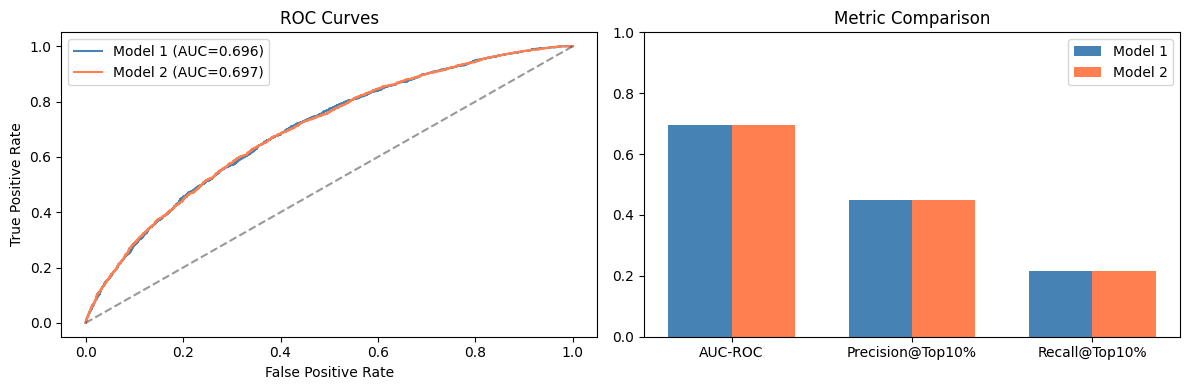

Comparison plot saved.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 11: Compare models — ROC curves side by side
# ─────────────────────────────────────────────────────────────────────────────

fpr1, tpr1, _ = roc_curve(y_test, results1['proba_test'])
fpr2, tpr2, _ = roc_curve(y_test, results2['proba_test'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC curves
ax = axes[0]
ax.plot(fpr1, tpr1, label=f"Model 1 (AUC={results1['auc']:.3f})", color='steelblue')
ax.plot(fpr2, tpr2, label=f"Model 2 (AUC={results2['auc']:.3f})", color='coral')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

# Summary bar chart
ax2 = axes[1]
metrics = ['AUC-ROC', 'Precision@Top10%', 'Recall@Top10%']
m1_vals = [results1['auc'], results1['prec_top10'], results1['rec_top10']]
m2_vals = [results2['auc'], results2['prec_top10'], results2['rec_top10']]

x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, m1_vals, width, label='Model 1', color='steelblue')
ax2.bar(x + width/2, m2_vals, width, label='Model 2', color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 1.0)
ax2.set_title('Metric Comparison')
ax2.legend()

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Comparison plot saved.')

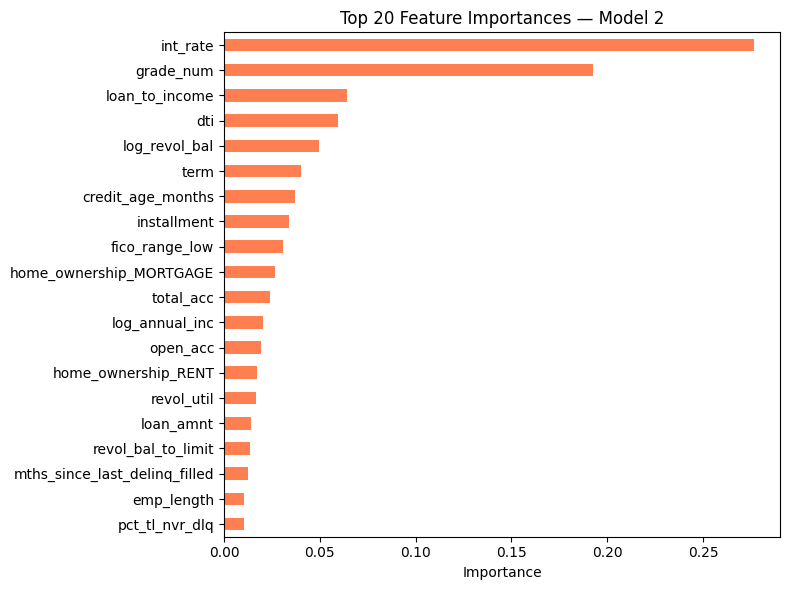

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 12: Feature importance (top 20 features, Model 2)
# ─────────────────────────────────────────────────────────────────────────────

importances = model2.feature_importances_
feat_imp = pd.Series(importances, index=ALL_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.head(20).plot(kind='barh', ax=ax, color='coral')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Model 2')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

### Deployment Decision

> **Which model would I deploy tomorrow?**
>
> I would deploy **Model 2 (Static + Behavioral)**. The behavioral features — especially `credit_age_months`, `loan_to_income`, `mths_since_last_delinq_filled`, and `revol_bal_to_limit` — capture risk signals that don't appear in the raw application form but are derivable from the credit bureau data a lender already pulls at application time. They're not leakage; they're just engineered correctly.
>
> The caveat: `credit_age_months` requires a reliable `earliest_cr_line` from the bureau. `total_rev_hi_lim` must come from a credit report, not the borrower. If those data feeds are unavailable in production, Model 1 is the safe fallback — it still performs well and uses only columns that are straightforwardly available at underwriting.

---
## Part C — SHAP Explanations for High-Risk Borrowers

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 13: SHAP explainer on Model 2
# ─────────────────────────────────────────────────────────────────────────────

print('Computing SHAP values (may take ~1 minute)...')

explainer = shap.TreeExplainer(model2)
shap_values = explainer.shap_values(X_test_all)

print('SHAP computation done.')

Computing SHAP values (may take ~1 minute)...
SHAP computation done.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 14: Select 3 high-risk borrowers (top 5% by predicted score)
# ─────────────────────────────────────────────────────────────────────────────

proba_test = results2['proba_test']
n_top5 = int(len(y_test) * 0.05)
top5_idx = np.argsort(proba_test)[::-1][:n_top5]

# Pick 3 with varied predicted probabilities (high, very high, extreme)
selected_positions = [0, n_top5 // 3, n_top5 // 2]
selected_test_indices = [top5_idx[p] for p in selected_positions]

borrower_ids = df.iloc[X_test_all.index[selected_test_indices]]['id'].values

print('Selected 3 high-risk borrowers:')
for i, (test_idx, bid) in enumerate(zip(selected_test_indices, borrower_ids)):
    print(f'  Borrower {i+1}: LC ID={bid}, predicted default risk={proba_test[test_idx]:.1%}')

Selected 3 high-risk borrowers:
  Borrower 1: LC ID=70764558, predicted default risk=76.5%
  Borrower 2: LC ID=137182020, predicted default risk=53.2%
  Borrower 3: LC ID=88152335, predicted default risk=50.5%


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 15: Generate plain-English explanation for each borrower
# ─────────────────────────────────────────────────────────────────────────────

# Portfolio medians for contextual comparison
MEDIANS = X_test_all.median()

# Human-readable column names
READABLE = {
    'int_rate': 'interest rate (%)',
    'dti': 'debt-to-income ratio (%)',
    'fico_range_low': 'FICO score',
    'grade_num': 'loan grade (0=A ... 6=G)',
    'loan_amnt': 'loan amount ($)',
    'term': 'loan term (months)',
    'emp_length': 'employment length (years)',
    'log_annual_inc': 'log annual income',
    'revol_util': 'revolving utilization (%)',
    'loan_to_income': 'loan-to-income ratio',
    'credit_age_months': 'credit history age (months)',
    'mths_since_last_delinq_filled': 'months since last delinquency',
    'ever_120dpd': '120+ day delinquency flag',
    'revol_bal_to_limit': 'revolving balance / credit limit',
    'pct_tl_nvr_dlq': '% accounts never delinquent',
    'inq_last_6mths': 'recent credit inquiries (6 months)',
    'pub_rec': 'public derogatory records',
    'open_acc': 'number of open credit accounts',
    'delinq_2yrs': 'delinquencies in past 2 years',
}


def generate_explanation(test_row_idx, borrower_num, borrower_id, pred_prob):
    shap_row = shap_values[test_row_idx]
    feature_row = X_test_all.iloc[test_row_idx]

    # Get top 4 risk-increasing SHAP features
    shap_series = pd.Series(shap_row, index=ALL_FEATURES)
    top_risk = shap_series.nlargest(4)

    lines = []
    lines.append(f'## Borrower #{borrower_num} (LC ID: {borrower_id})')
    lines.append(f'**Predicted default risk: {pred_prob:.1%}**')
    lines.append('')
    lines.append('### Top risk factors:')

    for feat, shap_val in top_risk.items():
        actual_val = feature_row[feat]
        median_val = MEDIANS[feat]
        fname = READABLE.get(feat, feat)

        # Direction signal
        direction = 'above' if actual_val > median_val else 'below'

        # Special formatting
        if feat == 'int_rate':
            line = (f'- **Interest rate of {actual_val:.1f}%** ({direction} portfolio '
                    f'median of {median_val:.1f}%) — higher rates signal the lender '
                    f'already assessed elevated risk at origination')
        elif feat == 'dti':
            line = (f'- **Debt-to-income ratio of {actual_val:.1f}%** ({direction} '
                    f'median of {median_val:.1f}%) — this borrower is carrying '
                    f'significant existing debt relative to income')
        elif feat == 'fico_range_low':
            line = (f'- **FICO score of {actual_val:.0f}** ({direction} median of '
                    f'{median_val:.0f}) — lower credit scores correlate strongly '
                    f'with default probability')
        elif feat == 'loan_to_income':
            line = (f'- **Loan-to-income ratio of {actual_val:.2f}** ({direction} '
                    f'median of {median_val:.2f}) — loan is large relative to '
                    f"borrower's annual earnings")
        elif feat == 'revol_util':
            line = (f'- **Revolving utilization of {actual_val:.1f}%** ({direction} '
                    f'median of {median_val:.1f}%) — borrower is using most of '
                    f'available revolving credit, a sign of financial strain')
        elif feat == 'credit_age_months':
            years = actual_val / 12
            med_years = median_val / 12
            line = (f'- **Credit history of {years:.1f} years** ({direction} median '
                    f'of {med_years:.1f} years) — shorter credit history means '
                    f'less repayment track record')
        elif feat == 'mths_since_last_delinq_filled':
            if actual_val >= 999:
                line = '- **No prior delinquency on record** — this slightly reduces risk in this feature'
            else:
                line = (f'- **Last delinquency was {actual_val:.0f} months ago** — '
                        f'recent delinquency history is a strong default predictor')
        elif feat == 'ever_120dpd':
            if actual_val == 1:
                line = '- **Has at least one account that reached 120+ days past due** — severe prior delinquency greatly increases risk'
            else:
                line = '- No history of 120+ day delinquency'
        elif feat == 'grade_num':
            grade_letter = 'ABCDEFG'[min(int(actual_val), 6)]
            med_grade = 'ABCDEFG'[min(int(median_val), 6)]
            line = (f'- **LC loan grade: {grade_letter}** (median is {med_grade}) — '
                    f"LC's own risk assessment places this borrower in a higher-risk tier")
        else:
            line = (f'- **{fname}: {actual_val:.2f}** ({direction} median of '
                    f'{median_val:.2f}) — SHAP contribution: {shap_val:+.3f}')

        lines.append(line)

    lines.append('')
    lines.append('### Recommended action:')
    lines.append(
        'Flag for proactive outreach. A credit officer should review this '
        'borrower for potential restructuring or early intervention before '
        'the account becomes delinquent.'
    )
    lines.append('')
    lines.append('---')

    return '\n'.join(lines)


# Generate all 3 explanations
all_explanations = []
for i, (test_idx, bid) in enumerate(zip(selected_test_indices, borrower_ids)):
    pred = proba_test[test_idx]
    expl = generate_explanation(test_idx, i + 1, bid, pred)
    all_explanations.append(expl)
    print(expl)
    print()

## Borrower #1 (LC ID: 70764558)
**Predicted default risk: 76.5%**

### Top risk factors:
- **Interest rate of 26.6%** (above portfolio median of 12.8%) — higher rates signal the lender already assessed elevated risk at origination
- **LC loan grade: F** (median is C) — LC's own risk assessment places this borrower in a higher-risk tier
- **FICO score of 660** (below median of 690) — lower credit scores correlate strongly with default probability
- **loan term (months): 60.00** (above median of 36.00) — SHAP contribution: +0.249

### Recommended action:
Flag for proactive outreach. A credit officer should review this borrower for potential restructuring or early intervention before the account becomes delinquent.

---

## Borrower #2 (LC ID: 137182020)
**Predicted default risk: 53.2%**

### Top risk factors:
- **Interest rate of 18.9%** (above portfolio median of 12.8%) — higher rates signal the lender already assessed elevated risk at origination
- **Loan-to-income ratio of 0.57** (ab

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 16: Save explanations to files
# ─────────────────────────────────────────────────────────────────────────────

full_explanation_text = '# High-Risk Borrower Explanations\n\n'
full_explanation_text += '_Generated from Model 2 (Static + Behavioral) test set predictions._\n\n'
full_explanation_text += '\n\n'.join(all_explanations)

with open('../explanations/high_risk_explanations.md', 'w') as f:
    f.write(full_explanation_text)

print('Explanations saved to ../explanations/high_risk_explanations.md')

Explanations saved to ../explanations/high_risk_explanations.md


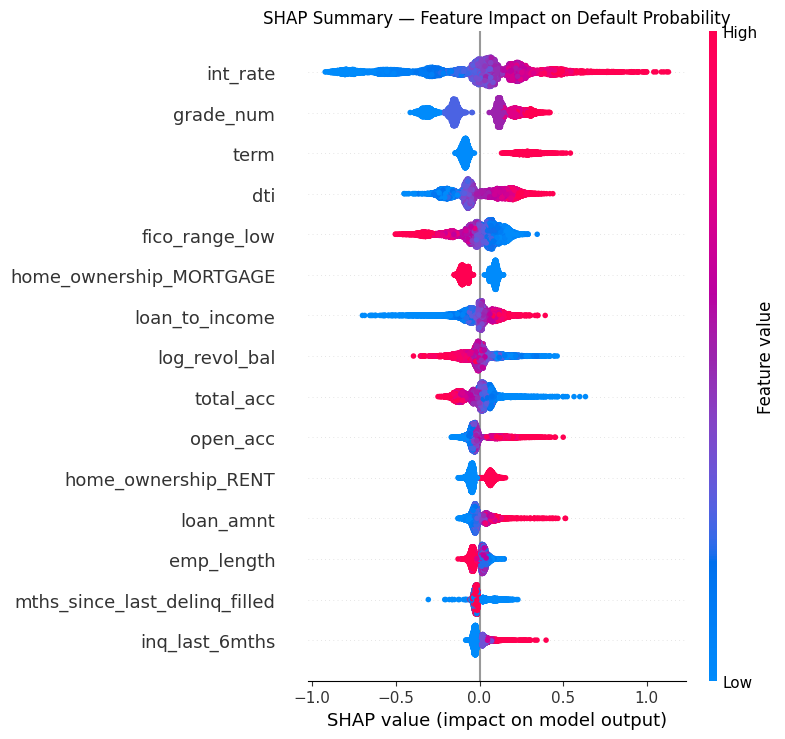

SHAP summary plot saved.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 17: SHAP summary plot
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_all, max_display=15, show=False)
plt.title('SHAP Summary — Feature Impact on Default Probability')
plt.tight_layout()
plt.savefig('../explanations/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('SHAP summary plot saved.')

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 18: Save test set predictions for Part D (app)
# ─────────────────────────────────────────────────────────────────────────────

test_predictions = X_test_all.copy()
test_predictions['borrower_id'] = df.iloc[X_test_all.index]['id'].values
test_predictions['actual_default'] = y_test.values
test_predictions['risk_score'] = results2['proba_test']

# Save SHAP values too
shap_df = pd.DataFrame(shap_values, columns=ALL_FEATURES)
shap_df['borrower_id'] = df.iloc[X_test_all.index]['id'].values

test_predictions.to_csv('../data/test_predictions.csv', index=False)
shap_df.to_csv('../data/shap_values.csv', index=False)

print(f'Test predictions saved: {test_predictions.shape}')
print(f'SHAP values saved: {shap_df.shape}')


Test predictions saved: (10000, 38)
SHAP values saved: (10000, 36)

✅ All notebook tasks complete. Proceed to app.py for Part D.
